This data set has 215 candidates with everything from their 10th grades scores to their 
interview performance. Some got placed. SOme did'nt. Let's figure out why?

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC # (Support Vector Classifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [56]:
df = pd.read_csv('Downloads/Job_Placement_Data_Enhanced.csv')
df.head()

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score,company_tier,job_competition_level
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,3,98,1,0,94,Mid,Medium
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,4,88,1,1,54,MNC,Low
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,2,41,1,1,82,Startup,Low
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,4,41,0,0,50,MNC,High
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,4,67,0,0,67,Mid,High


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 215 non-null    object 
 1   ssc_percentage         215 non-null    float64
 2   ssc_board              215 non-null    object 
 3   hsc_percentage         215 non-null    float64
 4   hsc_board              215 non-null    object 
 5   hsc_subject            215 non-null    object 
 6   degree_percentage      215 non-null    float64
 7   undergrad_degree       215 non-null    object 
 8   work_experience        215 non-null    object 
 9   emp_test_percentage    215 non-null    float64
 10  specialisation         215 non-null    object 
 11  mba_percent            215 non-null    float64
 12  status                 215 non-null    object 
 13  years_experience       215 non-null    int64  
 14  skills_match_percent   215 non-null    int64  
 15  num_ce

PLACEMENT RESULTS: status
Placed        148
Not Placed     67
Name: count, dtype: int64


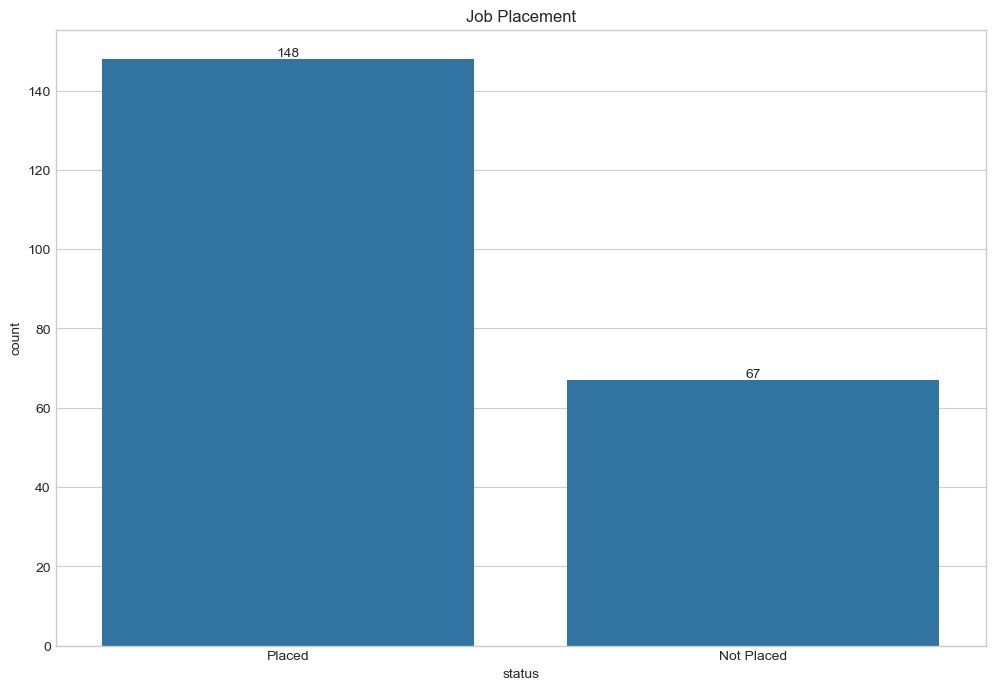

In [60]:
# Exploratory Data Analysis.
status_counts = df['status'].value_counts()
print('PLACEMENT RESULTS:', status_counts)

plt.figure(figsize=(12,8))
ax = sns.countplot(x='status', data=df)
ax.bar_label(ax.containers[0])
plt.title('Job Placement')
plt.show()

69% got placed, 31% didn't.
Note: This is an imbalanced dataset. More placed  than not Placed. Our model will get biased

In [63]:
# Checking missing values and duplicates.
df.duplicated().sum()

0

In [65]:
df.isnull().sum()

gender                   0
ssc_percentage           0
ssc_board                0
hsc_percentage           0
hsc_board                0
hsc_subject              0
degree_percentage        0
undergrad_degree         0
work_experience          0
emp_test_percentage      0
specialisation           0
mba_percent              0
status                   0
years_experience         0
skills_match_percent     0
num_certifications       0
internship_completed     0
interview_score          0
company_tier             0
job_competition_level    0
dtype: int64

**Clean data**: No missing values, no duplicates.

In [68]:
print('NUMERICAL FEATURES SUMMARY')
print('='*80)
df.describe()

NUMERICAL FEATURES SUMMARY


,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,2.483721,70.413953,2.423256,0.483721,74.046512
std,10.827205,10.897509,7.358743,13.275956,5.833385,1.701694,17.235065,1.708259,0.500901,14.602447
min,40.890000,37.000000,50.000000,50.000000,51.210000,0.000000,40.000000,0.000000,0.000000,50.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,1.000000,58.000000,1.000000,0.000000,62.500000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,3.000000,71.000000,3.000000,0.000000,74.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,4.000000,86.000000,4.000000,1.000000,86.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,5.000000,99.000000,5.000000,1.000000,99.000000


In [70]:
# Categorical features breakdown
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('status')
print('CATEGORICAL FEATURES BREAKDOWN')
print('='*50)
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())

CATEGORICAL FEATURES BREAKDOWN

gender:
gender
M    139
F     76

ssc_board:
ssc_board
Central    116
Others      99

hsc_board:
hsc_board
Others     131
Central     84

hsc_subject:
hsc_subject
Commerce    113
Science      91
Arts         11

undergrad_degree:
undergrad_degree
Comm&Mgmt    145
Sci&Tech      59
Others        11

work_experience:
work_experience
No     141
Yes     74

specialisation:
specialisation
Mkt&Fin    120
Mkt&HR      95

company_tier:
company_tier
Mid        75
MNC        73
Startup    67

job_competition_level:
job_competition_level
High      75
Low       71
Medium    69


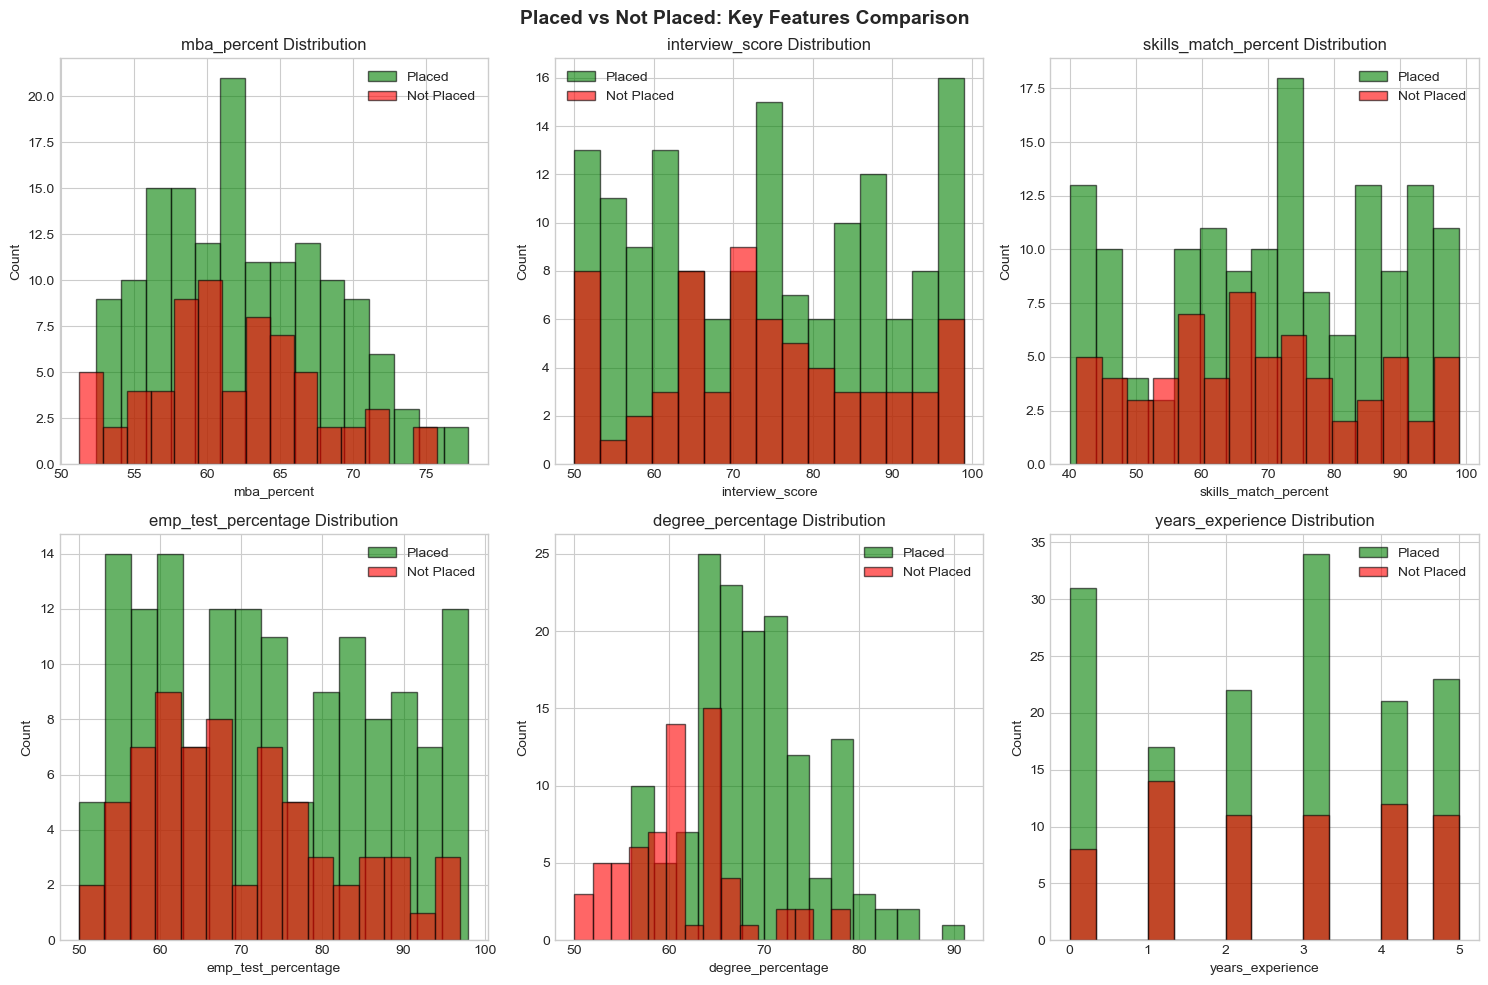

In [72]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
# Key numerical feature comparison
key_features = ['mba_percent', 'interview_score', 'skills_match_percent',
                'emp_test_percentage', 'degree_percentage', 'years_experience']

for idx, col in enumerate(key_features):
    ax = axes[idx//3, idx%3]
    placed = df[df['status']=='Placed'][col]
    not_placed = df[df['status']=='Not Placed'][col]

    ax.hist(placed, bins=15, alpha=0.6, color='green', label='Placed', edgecolor='black')
    ax.hist(not_placed, bins=15, alpha=0.6, color='red', label='Not Placed', edgecolor='black')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'{col} Distribution')
    ax.legend()

plt.suptitle('Placed vs Not Placed: Key Features Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

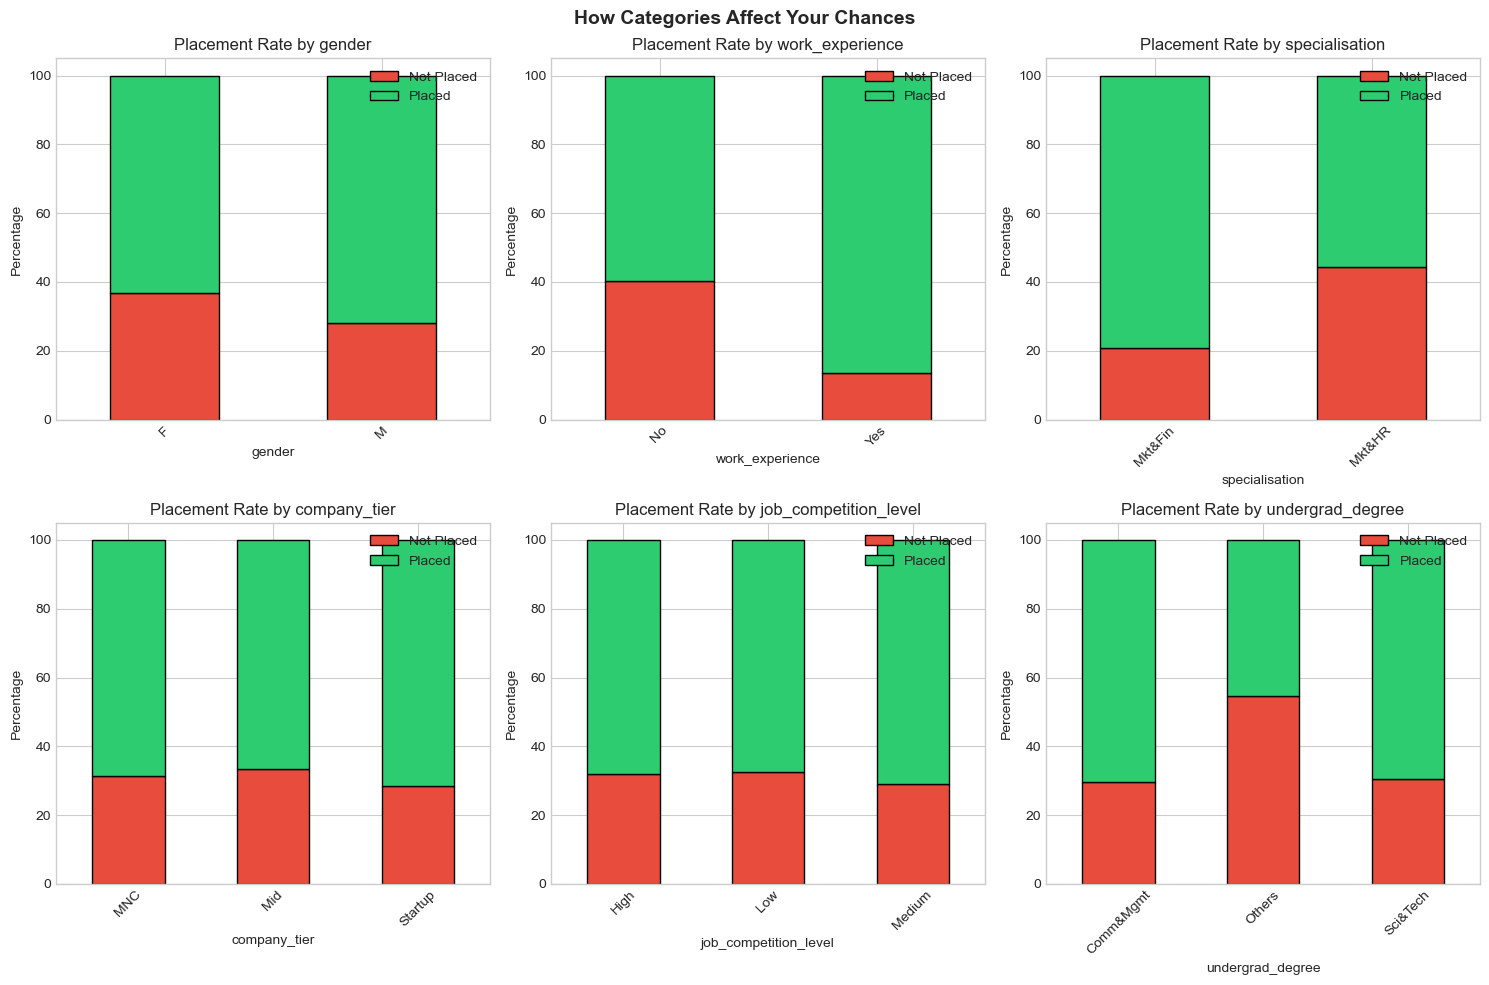

In [73]:
# Categorical features vs Placement 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
cat_features = ['gender', 'work_experience', 'specialisation', 'company_tier', 'job_competition_level',
                'undergrad_degree']
for idx, col in enumerate(cat_features):
    ax = axes[idx//3, idx%3]
    cross = pd.crosstab(df[col], df['status'], normalize='index')*100
    cross.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], ax=ax,edgecolor='black')
    ax.set_title(f'Placement Rate by {col}')
    ax.set_ylabel('Percentage')
    ax.legend(['Not Placed', 'Placed'], loc='upper right')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('How Categories Affect Your Chances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

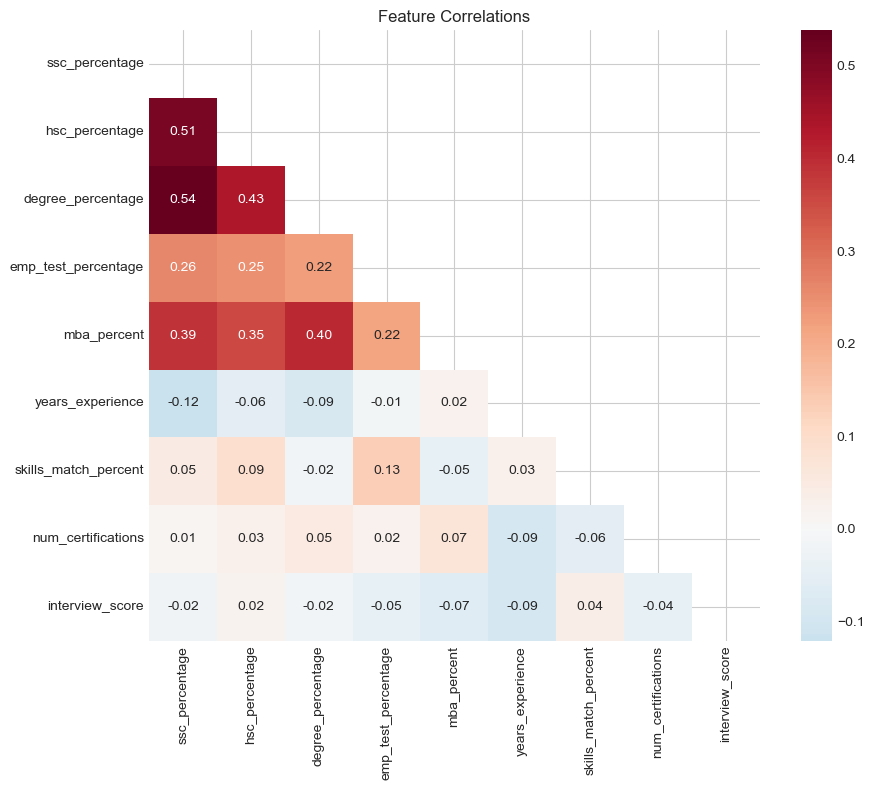

In [74]:
# Correlation heatmap for numerical features.
num_cols_for_corr = ['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'emp_test_percentage',
                     'mba_percent', 'years_experience', 'skills_match_percent', 'num_certifications',
                     'interview_score']

fig, ax = plt.subplots(figsize=(10,8))
corr = df[num_cols_for_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax, square=True)
ax.set_title('Feature Correlations')
plt.tight_layout()
plt.show()


No major multicollinearity issues to worry about

In [76]:
# T-tests for numerical features
print("STATISTICAL SIGNIFICANCE: NUMERICAL FEATURES")
print("="*60)
print("\nH0: No difference between Placed and Not Placed")
print("H1: Significant difference exists")
print("-"*60)

placed = df[df['status'] == 'Placed']
not_placed = df[df['status'] == 'Not Placed']

stat_results = []
for col in num_cols_for_corr:
    t_stat, p_val = stats.ttest_ind(placed[col], not_placed[col])
    
    # Cohen's d
    pooled_std = np.sqrt((placed[col].std()**2 + not_placed[col].std()**2) / 2)
    cohens_d = (placed[col].mean() - not_placed[col].mean()) / pooled_std if pooled_std > 0 else 0
    
    stat_results.append({
        'Feature': col,
        'Placed_Mean': placed[col].mean(),
        'NotPlaced_Mean': not_placed[col].mean(),
        'Difference': placed[col].mean() - not_placed[col].mean(),
        'T_Stat': t_stat,
        'P_Value': p_val,
        'Cohens_d': cohens_d,
        'Significant': 'YES' if p_val < 0.05 else 'NO'
    })

stat_df = pd.DataFrame(stat_results).sort_values('P_Value')

for _, row in stat_df.iterrows():
    sig = "***" if row['Significant'] == 'YES' else "   "
    print(f"{sig} {row['Feature']:25s} | p={row['P_Value']:.4f} | d={row['Cohens_d']:+.3f} | {row['Significant']}")

print("-"*60)
print(f"\nSignificant features: {(stat_df['Significant']=='YES').sum()}/{len(stat_df)}")

STATISTICAL SIGNIFICANCE: NUMERICAL FEATURES

H0: No difference between Placed and Not Placed
H1: Significant difference exists
------------------------------------------------------------
*** ssc_percentage            | p=0.0000 | d=+1.657 | YES
*** hsc_percentage            | p=0.0000 | d=+1.198 | YES
*** degree_percentage         | p=0.0000 | d=+1.181 | YES
    emp_test_percentage       | p=0.0617 | d=+0.284 | NO
    mba_percent               | p=0.2614 | d=+0.167 | NO
    skills_match_percent      | p=0.2915 | d=+0.158 | NO
    years_experience          | p=0.6297 | d=-0.072 | NO
    interview_score           | p=0.8872 | d=+0.021 | NO
    num_certifications        | p=0.9755 | d=+0.005 | NO
------------------------------------------------------------

Significant features: 3/9


In [77]:
# Chi-square tests for categorical features
print("STATISTICAL SIGNIFICANCE: CATEGORICAL FEATURES")
print("="*60)
print("\nChi-Square Tests for Independence")
print("-"*60)

chi_results = []
for col in cat_cols:
    contingency = pd.crosstab(df[col], df['status'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    
    # Cramer's V
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    chi_results.append({
        'Feature': col,
        'Chi2': chi2,
        'P_Value': p_val,
        'Cramers_V': cramers_v,
        'Significant': 'YES' if p_val < 0.05 else 'NO'
    })

chi_df = pd.DataFrame(chi_results).sort_values('P_Value')

for _, row in chi_df.iterrows():
    sig = "***" if row['Significant'] == 'YES' else "   "
    print(f"{sig} {row['Feature']:25s} | p={row['P_Value']:.4f} | V={row['Cramers_V']:.3f} | {row['Significant']}")

print("-"*60)
print(f"\nSignificant features: {(chi_df['Significant']=='YES').sum()}/{len(chi_df)}")


STATISTICAL SIGNIFICANCE: CATEGORICAL FEATURES

Chi-Square Tests for Independence
------------------------------------------------------------
*** work_experience           | p=0.0001 | V=0.265 | YES
*** specialisation            | p=0.0004 | V=0.241 | YES
    undergrad_degree          | p=0.2266 | V=0.118 | NO
    gender                    | p=0.2398 | V=0.080 | NO
    hsc_subject               | p=0.5727 | V=0.072 | NO
    ssc_board                 | p=0.6898 | V=0.027 | NO
    company_tier              | p=0.8129 | V=0.044 | NO
    job_competition_level     | p=0.8926 | V=0.033 | NO
    hsc_board                 | p=0.9223 | V=0.007 | NO
------------------------------------------------------------

Significant features: 2/9


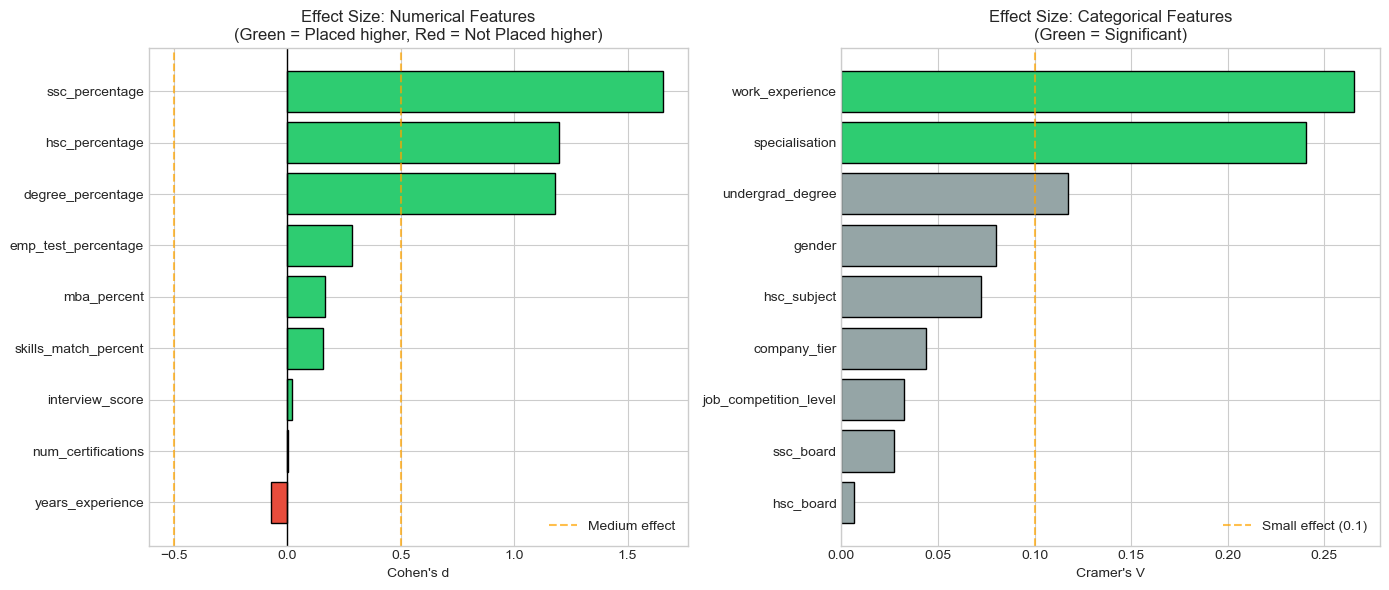

In [78]:
# Visualize effect sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cohen's d for numerical
stat_df_sorted = stat_df.sort_values('Cohens_d')
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in stat_df_sorted['Cohens_d']]
axes[0].barh(stat_df_sorted['Feature'], stat_df_sorted['Cohens_d'], color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, label='Medium effect')
axes[0].axvline(x=-0.5, color='orange', linestyle='--', alpha=0.7)
axes[0].set_xlabel("Cohen's d")
axes[0].set_title('Effect Size: Numerical Features\n(Green = Placed higher, Red = Not Placed higher)')
axes[0].legend()

# Cramer's V for categorical
chi_df_sorted = chi_df.sort_values('Cramers_V')
colors_v = ['#2ecc71' if row['Significant']=='YES' else '#95a5a6' for _, row in chi_df_sorted.iterrows()]
axes[1].barh(chi_df_sorted['Feature'], chi_df_sorted['Cramers_V'], color=colors_v, edgecolor='black')
axes[1].axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Small effect (0.1)')
axes[1].set_xlabel("Cramer's V")
axes[1].set_title('Effect Size: Categorical Features\n(Green = Significant)')
axes[1].legend()

plt.tight_layout()
plt.show()


- Bigger bars = stronger relationship with placement 
- Green numerical features = placed candidates score higher
- These are the features our models should lean on

# Model Building

In [82]:
df_model = df.copy()

# Encoding categorical variables
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Encode target
le_target = LabelEncoder()
df_model['status'] = le_target.fit_transform(df_model['status'])
print(f'Target encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

# Features and target
X = df_model.drop('status', axis=1)
y = df_model['status']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTraining: {len(X_train)} | Test: {len(X_test)}')
print(f'Features: {X.shape[1]}')

Target encoding: {'Not Placed': 0, 'Placed': 1}

Training: 172 | Test: 43
Features: 19


In [93]:
# Models
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), False),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42), False),
    'Gradient Boosting':(GradientBoostingClassifier(random_state=42), False),
    'K-Nearest Neighbours':(KNeighborsClassifier(n_neighbors=5), True),
    'SVM':(SVC(kernel='rbf', probability=True, random_state=42),True),
    'Naive Bayes':(GaussianNB(), True)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


print(f"{'Model':<25} | {'Test Acc':>10} | {'CV Mean':>10} | {'F1':>8} | {'ROC-AUC':>8}")
print("-"*70)

for name, (model, use_scaled) in models.items():
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0
    
    cv_X = X_train_scaled if use_scaled else X_train
    cv_scores = cross_val_score(model, cv_X, y_train, cv=cv)
    
    results.append({
        'Model': name,
        'Test_Acc': acc,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'F1': f1,
        'ROC_AUC': roc
    })
    
    print(f"{name:<25} | {acc*100:>9.2f}% | {cv_scores.mean()*100:>9.2f}% | {f1:>7.3f} | {roc:>7.3f}")

Model                     |   Test Acc |    CV Mean |       F1 |  ROC-AUC
----------------------------------------------------------------------
Logistic Regression       |     83.72% |     85.45% |   0.877 |   0.926
Decision Tree             |     72.09% |     79.03% |   0.806 |   0.647
Random Forest             |     81.40% |     81.36% |   0.875 |   0.919
Gradient Boosting         |     83.72% |     82.52% |   0.889 |   0.918
K-Nearest Neighbours      |     83.72% |     78.45% |   0.892 |   0.792
SVM                       |     90.70% |     85.41% |   0.935 |   0.897
Naive Bayes               |     86.05% |     81.34% |   0.900 |   0.949


- Here SVM is performing best with test accuracy of 90.70% and ROC-AUC:0.897.

In [98]:
# Best model deep dive
results_df = pd.DataFrame(results).sort_values('Test_Acc', ascending=False)
best_name = results_df.iloc[0]['Model']
best_model = models[best_name][0]
use_scaled = models[best_name][1]

X_te_final = X_test_scaled if use_scaled else X_test
y_pred_final = best_model.predict(X_te_final)
y_prob_final = best_model.predict_proba(X_te_final)[:, 1]

print(f"CHAMPION MODEL: {best_name}")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Not Placed', 'Placed']))

CHAMPION MODEL: SVM

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.91      0.77      0.83        13
      Placed       0.91      0.97      0.94        30

    accuracy                           0.91        43
   macro avg       0.91      0.87      0.88        43
weighted avg       0.91      0.91      0.90        43

